In [1]:
!pip install scikit-image
!pip install wandb
!pip install monai

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [76]:
data_path = "heart"

In [79]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import monai
import torch
import re
import torchvision.transforms as transforms
from PIL import Image
from monai.transforms import LoadImage

def build_dict_heart(data_path, mode='train'):
    """
    This function returns a list of dictionaries, each dictionary containing the keys 'img' and 'mask' 
    that returns the path to the corresponding image.
    
    Args:
        data_path (str): path to the root folder of the data set.
        mode (str): subset used. Must correspond to 'train', 'val' or 'test'.
        
    Returns:
        (List[Dict[str, str]]) list of the dictionaries containing the paths of X-ray images and masks.
    """
    # test if mode is correct
    if mode not in ["train", "val", "test"]:
        raise ValueError(f"Please choose a mode in ['train', 'val', 'test']. Current mode is {mode}.")
    
    # define empty dictionary
    dicts = []
    # list all .png files in directory, including the path
    paths_xray = glob.glob(os.path.join(data_path, mode, 'img', '*.nii'))
    # make a corresponding list for all the mask files
    for xray_path in paths_xray:
        if mode == 'test':
            suffix = 'val'
        else:
            suffix = mode
        # find the binary mask that belongs to the original image, based on indexing in the filenam
        numbers = re.findall(r'\d+', xray_path)
        image_path = os.path.join(data_path, mode, 'img', f'DCM{numbers[0]}Gate{numbers[1]}.nii')
        # define path to mask file based on this index and add to list of mask paths
        mask_path = os.path.join(data_path, mode, 'mask', f'DCM{numbers[0]}-OH-AL_V2_{numbers[1]}.nii')
        if os.path.exists(mask_path):
            dicts.append({'img': image_path , 'mask': mask_path})
    return dicts

class MedMNISTData(monai.data.Dataset):
    
    def __init__(self, datafile, transform=None):
        self.data = datafile
        self.transform = transform
        
        
    def __getitem__(self, index):
        # Make getitem return a dictionary with keys ['img', 'mask'] for the image and mask respectively
        image = self.data[index]['img']
        mask = self.data[index]['mask']
        
        loader = LoadImage(image_only=True)
        image = loader(image)
        mask = loader(mask)
        if self.transform:
            image = self.transform(image)
        return {'img': image, 'mask': mask}
    
    def __len__(self):
        return len(self.data)
    
def dataviewer(image):
    loader = LoadImage(image_only=False)
    image, meta = loader(image)
    return image.shape, meta

def visualize_heart_sample(sample, title=None):
    # Visualize the x-ray and overlay the mask, using the dictionary as input
    image = np.squeeze(sample['img'])
    mask = np.squeeze(sample['mask'])
    
    plt.figure(figsize=[10,7])
    plt.imshow(image, 'gray')
    
    mask1 = np.ma.masked_where(mask != 1, mask)
    plt.imshow(mask1, 'Greens', alpha = 0.5, clim=[0,1], interpolation='nearest')

    mask2 = np.ma.masked_where(mask != 2, mask)
    plt.imshow(mask2, 'Reds', alpha = 0.5, clim=[0,1], interpolation='nearest')
    
    mask3 = np.ma.masked_where(mask != 3, mask)
    plt.imshow(mask3, 'Blues', alpha = 0.5, clim=[0,1], interpolation='nearest')
    if title is not None:
        plt.title(title)
    plt.show()

In [80]:
train_dict_list = build_dict_heart(data_path, mode='train')
shape, meta = dataviewer(train_dict_list[0]['img'])

print(meta)

{'sizeof_hdr': array(348, dtype=int32), 'extents': array(0, dtype=int32), 'session_error': array(0, dtype=int16), 'dim_info': array(0, dtype=uint8), 'dim': array([  3, 216, 256,  10,   1,   1,   1,   1], dtype=int16), 'intent_p1': array(0., dtype=float32), 'intent_p2': array(0., dtype=float32), 'intent_p3': array(0., dtype=float32), 'intent_code': array(0, dtype=int16), 'datatype': array(4, dtype=int16), 'bitpix': array(16, dtype=int16), 'slice_start': array(0, dtype=int16), 'pixdim': array([ 1.    ,  1.5625,  1.5625, 10.    ,  1.    ,  1.    ,  1.    ,
        1.    ], dtype=float32), 'vox_offset': array(0., dtype=float32), 'scl_slope': array(nan, dtype=float32), 'scl_inter': array(nan, dtype=float32), 'slice_end': array(0, dtype=int16), 'slice_code': array(0, dtype=uint8), 'xyzt_units': array(0, dtype=uint8), 'cal_max': array(0., dtype=float32), 'cal_min': array(0., dtype=float32), 'slice_duration': array(0., dtype=float32), 'toffset': array(0., dtype=float32), 'glmax': array(0, dtyp

In [81]:
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd,ScaleIntensityd
from monai.data import Dataset

data_transform = Compose([
    LoadImaged(keys=["img", "mask"]),
    EnsureChannelFirstd(keys=["img", "mask"]),
    ScaleIntensityd(keys=["img"])
])

train_dataset = Dataset(data=train_dict_list, transform=data_transform)

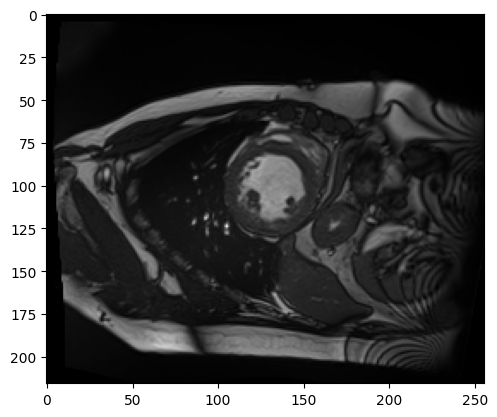

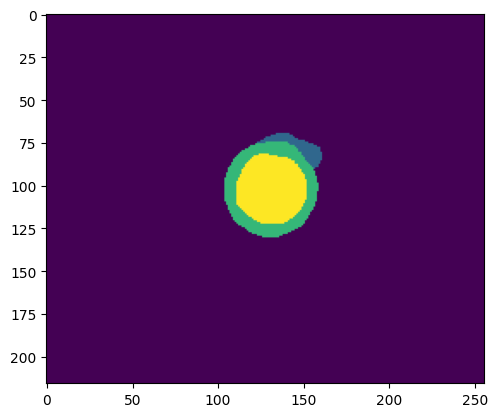

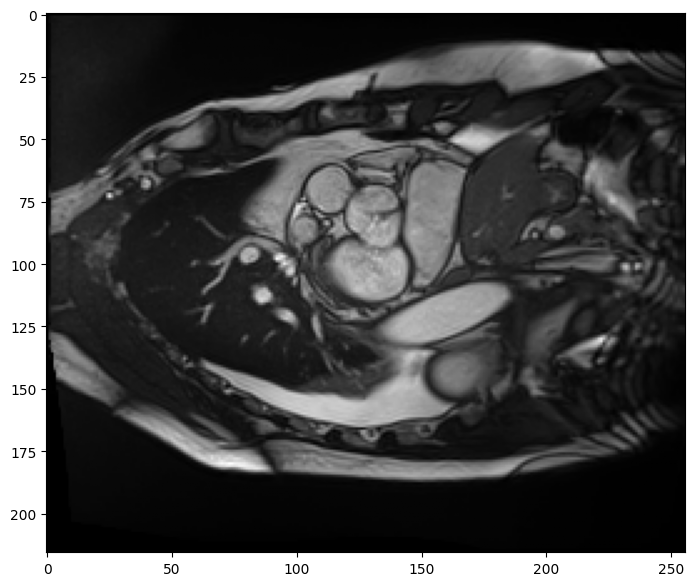

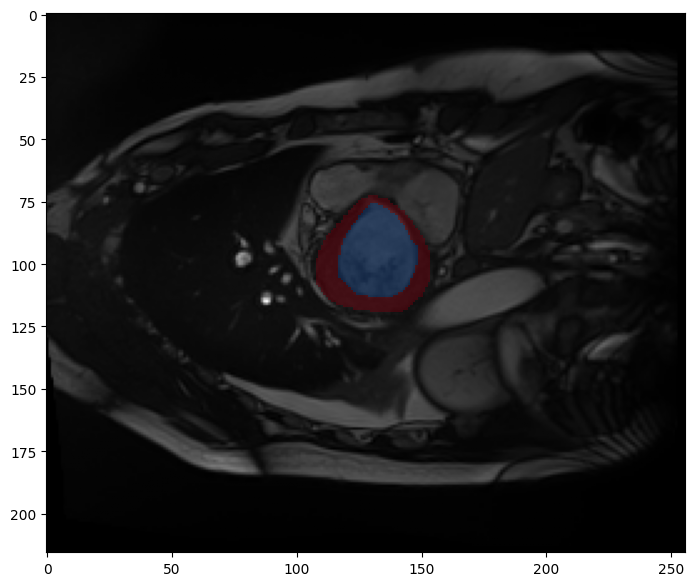

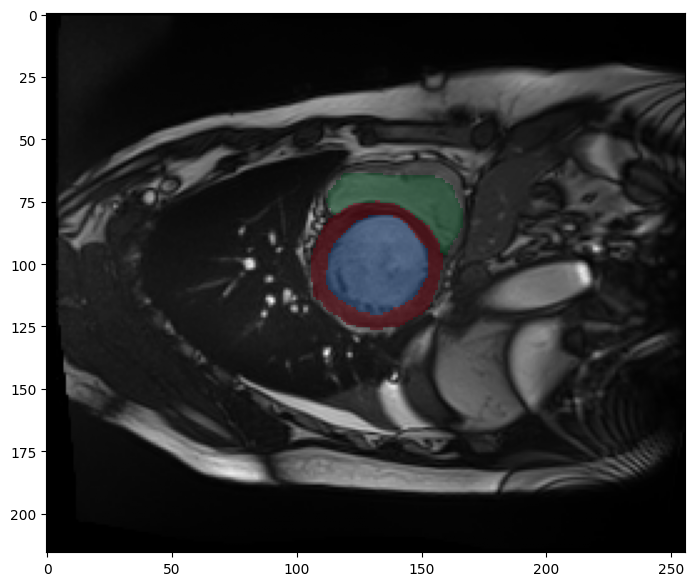

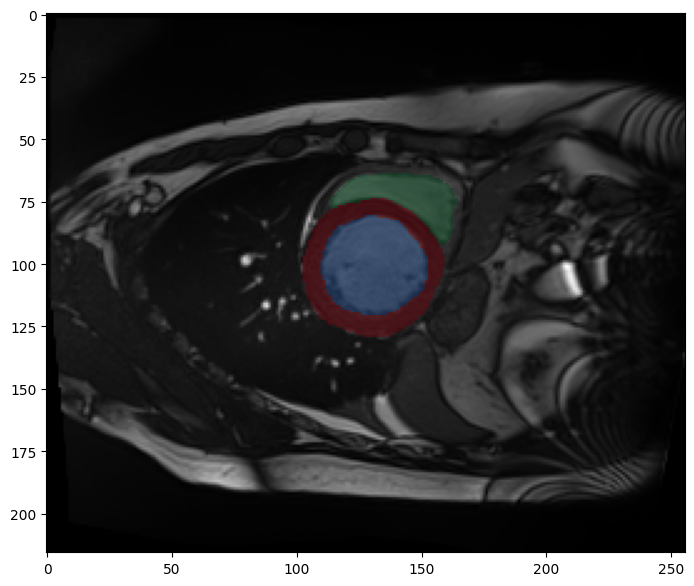

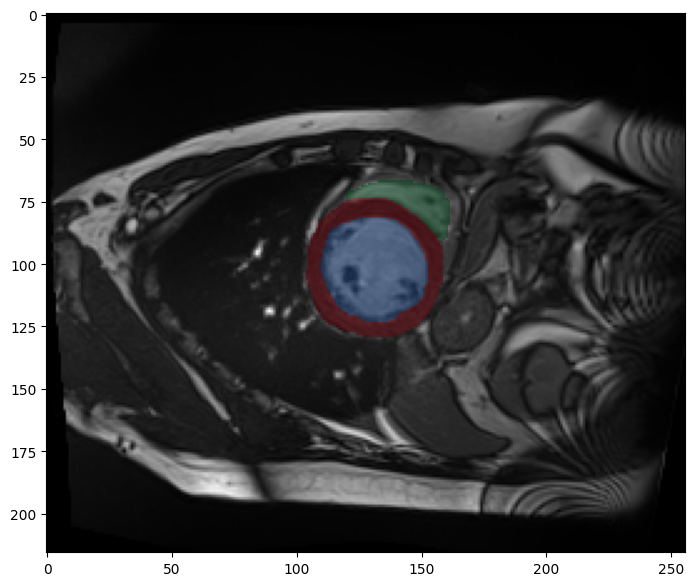

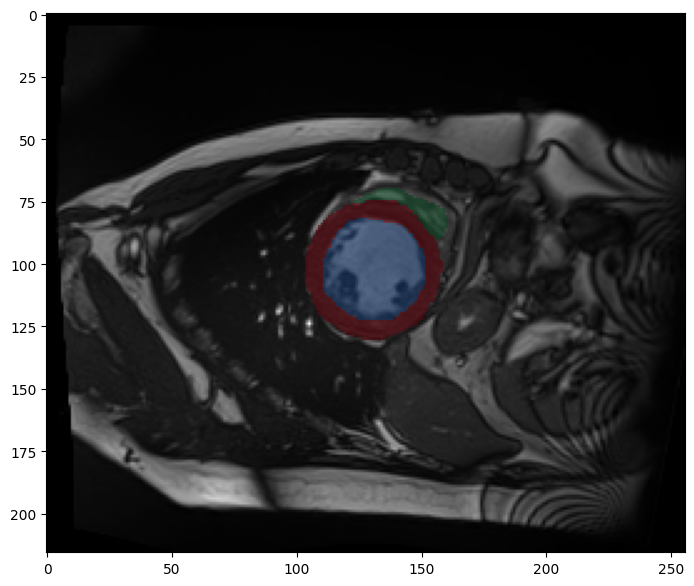

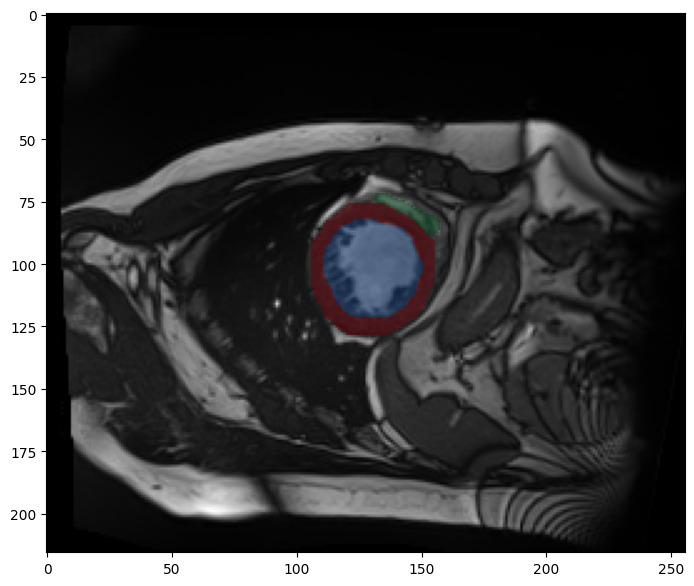

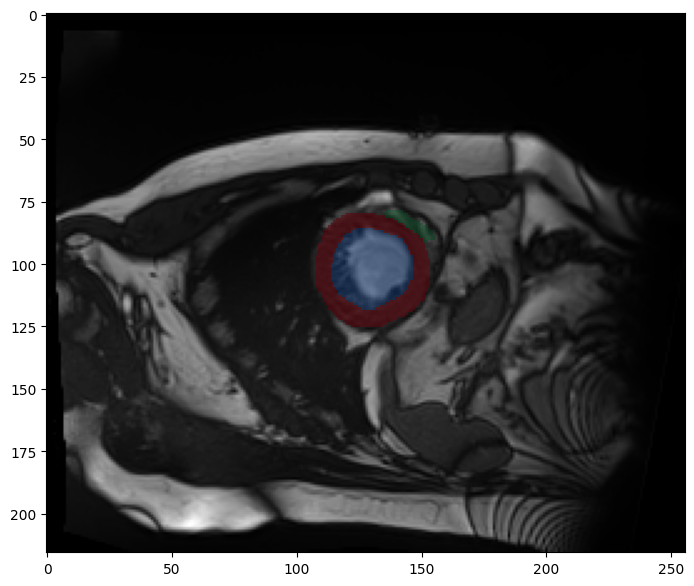

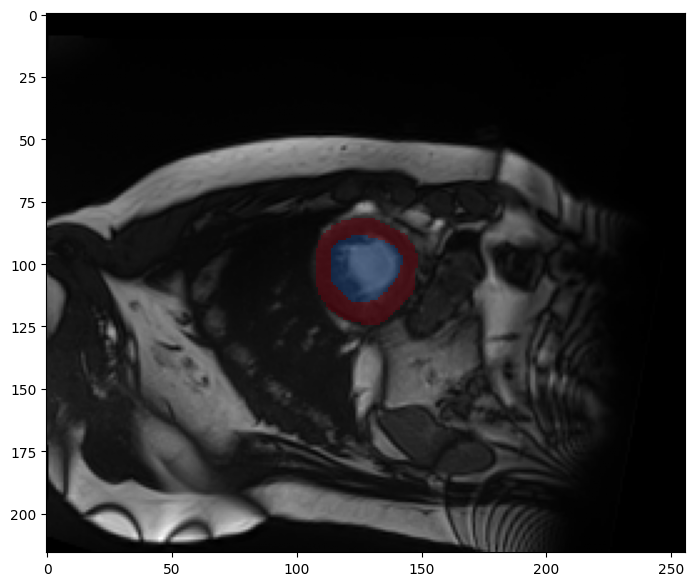

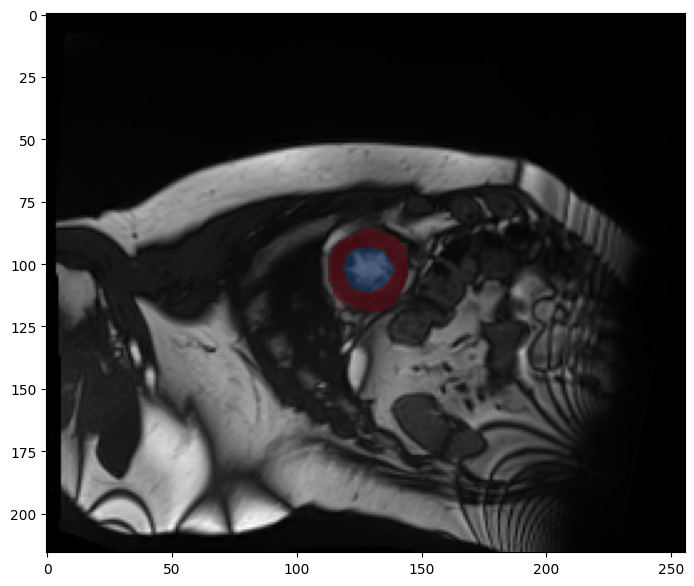

In [82]:
plt.figure()
plt.imshow(train_dataset[0]['img'][0,:,:,5].squeeze(), cmap='gray')
plt.show()

plt.imshow(train_dataset[0]['mask'][0,:,:,5].squeeze())
plt.show()

for i in range(shape[2]):
    single_data = train_dataset[0]
    sample_slice = {
    'img': single_data['img'][0,:, :, i],
    'mask': single_data['mask'][0,:, :, i]}
    visualize_heart_sample(sample_slice)


In [83]:
print(train_dataset.__len__())

for i in range(5):
    print(i)
    print('train')
    print(train_dataset[i]['img'].shape)
    print(train_dataset[i]['mask'].shape)

6
0
train
torch.Size([1, 216, 256, 10])
torch.Size([1, 216, 256, 10])
1
train
torch.Size([1, 232, 256, 10])
torch.Size([1, 232, 256, 10])
2
train
torch.Size([1, 232, 256, 10])
torch.Size([1, 232, 256, 10])
3
train
torch.Size([1, 256, 256, 10])
torch.Size([1, 256, 256, 10])
4
train
torch.Size([1, 256, 256, 10])
torch.Size([1, 256, 256, 10])
